# 01 — Análisis exploratorio y construcción de features

Notebook a cargo de Jesús SánchA). Carga el dataset Cora,
construye el grafo con NetworkX, realiza un análisis exploratorio de la
red y calcula las métricas relacionales que servirán de features para
los modelos de clasificación.

**Salidas que produce este notebook:**
- `data/graph.pkl`: grafo de NetworkX serializado.
- `data/features.csv`: tabla de features por nodo, lista para entrenar.

**Dataset:** Cora (red de citas entre artículos de Machine Learning).
2708 nodos, 5429 aristas dirigidas, 7 clases.

In [2]:
import pickle
from collections import Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética para las gráficas
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

## 1. Carga del dataset

Cora se distribuye en dos archivos de texto plano:

- **`cora.content`**: una línea por artículo. Formato:
  `<paper_id> <feature_0> <feature_1> ... <feature_1432> <clase>`
  donde las features son 0/1 (bag-of-words) y la clase es una de las
  7 subáreas de ML.

- **`cora.cites`**: una línea por cita. Formato:
  `<paper_citado> <paper_que_cita>`
  representa una arista dirigida del que cita al citado.

In [4]:
# Cargamos cora.content
# El separador es tabulador o espacios, dejamos que pandas autodetecte
cora_content = pd.read_csv(
    "../data/cora/cora.content",
    sep="\t",
    header=None,
)

# Renombramos columnas: la primera es el ID,  la última la clase, las del medio son features
n_features = cora_content.shape[1] - 2  # quitamos ID y clase
column_names = ["paper_id"] + [f"word_{i}" for i in range(n_features)] + ["class"]
cora_content.columns = column_names

print(f"Forma de cora.content: {cora_content.shape}")
print(f"Número de artículos: {len(cora_content)}")
print(f"Número de features bag-of-words: {n_features}")
print(f"\nPrimeras filas:")
cora_content.head()

Forma de cora.content: (2708, 1435)
Número de artículos: 2708
Número de features bag-of-words: 1433

Primeras filas:


,paper_id,word_0,word_1,word_2,word_3,word_4,word_5,word_6,word_7,word_8,...,word_1424,word_1425,word_1426,word_1427,word_1428,word_1429,word_1430,word_1431,word_1432,class
0,31336,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,Neural_Networks
1,1061127,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,Rule_Learning
2,1106406,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
3,13195,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
4,37879,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Probabilistic_Methods


### Distribución de clases

Antes de seguir, vemos cuántos artículos hay de cada subárea. Esto es importante porque si las clases están muy desbalanceadas tendremos que tenerlo en cuenta al evaluar los modelos, ya que la accuracy por sí sola puede ser engañosa en ese caso.

class
Neural_Networks           818
Probabilistic_Methods     426
Genetic_Algorithms        418
Theory                    351
Case_Based                298
Reinforcement_Learning    217
Rule_Learning             180
Name: count, dtype: int64


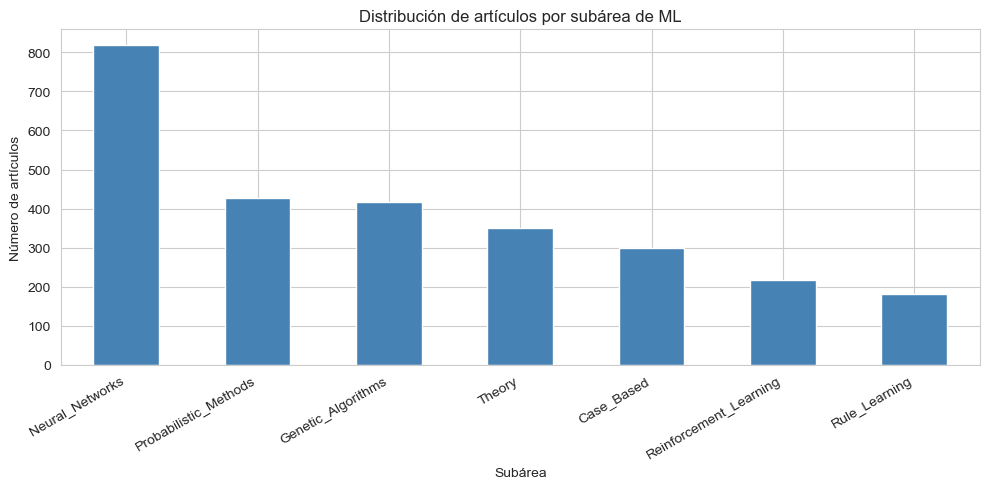

In [6]:
distribucion_clases = cora_content["class"].value_counts()
print(distribucion_clases)

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
distribucion_clases.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Distribución de artículos por subárea de ML")
ax.set_xlabel("Subárea")
ax.set_ylabel("Número de artículos")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [7]:
cora_cites = pd.read_csv(
    "../data/cora/cora.cites",
    sep="\t",
    header=None,
    names=["cited", "citing"],
)

print(f"Forma de cora.cites: {cora_cites.shape}")
print(f"Número de aristas (citas): {len(cora_cites)}")
print(f"\nPrimeras filas:")
cora_cites.head()

Forma de cora.cites: (5429, 2)
Número de aristas (citas): 5429

Primeras filas:


,cited,citing
0,35,1033
1,35,103482
2,35,103515
3,35,1050679
4,35,1103960


## 2. Construcción del grafo

Construimos el grafo con NetworkX. Decisión de diseño: aunque
las citas son dirigidas (un paper cita a otro, no al
revés), para este trabajo construimos un **grafo no dirigido**. Razones:

- Muchas métricas relacionales útiles (clustering coefficient, comunidades
  de Louvain) están definidas o son más interpretables en grafos no
  dirigidos.
- La relación "papers que se citan entre sí" captura proximidad temática
  con independencia de la dirección.
- En caso de querer información direccional, podemos calcularla aparte
  (in-degree, out-degree) sobre el grafo dirigido en paralelo.

Adicionalmente, nos quedaremos solo con la **componente conexa gigante**.
Los nodos aislados o en componentes pequeñas no aportan información
relacional útil y rompen el cálculo de varias métricas (closeness,
betweenness).

In [9]:
# Grafo no dirigido
G = nx.from_pandas_edgelist(cora_cites, source="citing", target="cited")

print(f"Antes de filtrar componentes:")
print(f"  Nodos: {G.number_of_nodes()}")
print(f"  Aristas: {G.number_of_edges()}")
print(f"  Número de componentes conexas: {nx.number_connected_components(G)}")

# Tamaño de las componentes
tamaños = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
print(f"  Tamaño de las 5 mayores componentes: {tamaños[:5]}")

Antes de filtrar componentes:
  Nodos: 2708
  Aristas: 5278
  Número de componentes conexas: 78
  Tamaño de las 5 mayores componentes: [2485, 26, 9, 8, 6]


In [10]:
# Identificamos la componente gigante
componente_gigante = max(nx.connected_components(G), key=len)
G = G.subgraph(componente_gigante).copy()

print(f"Después de filtrar la componente gigante:")
print(f"  Nodos: {G.number_of_nodes()}")
print(f"  Aristas: {G.number_of_edges()}")
print(f"  Densidad: {nx.density(G):.6f}")
print(f"  Es conexo: {nx.is_connected(G)}")

Después de filtrar la componente gigante:
  Nodos: 2485
  Aristas: 5069
  Densidad: 0.001642
  Es conexo: True


In [11]:
# Solo nos quedamos con los artículos que están en la componente gigante
nodos_gigante = set(G.nodes())
cora_content = cora_content[cora_content["paper_id"].isin(nodos_gigante)].copy()
cora_content = cora_content.reset_index(drop=True)

print(f"Artículos retenidos: {len(cora_content)}")
print(f"Coincide con nodos del grafo: {len(cora_content) == G.number_of_nodes()}")

Artículos retenidos: 2485
Coincide con nodos del grafo: True


## 3. Análisis exploratorio del grafo

Antes de calcular las métricas que serán features, hacemos un EDA del
grafo: distribución de grados, diámetro, asortatividad por clase
(¿papers de la misma subárea tienden a citarse entre sí?).

Estadísticas del grado:
  Media: 4.08
  Mediana: 3.00
  Min: 1, Max: 168
  Desv. típica: 5.41


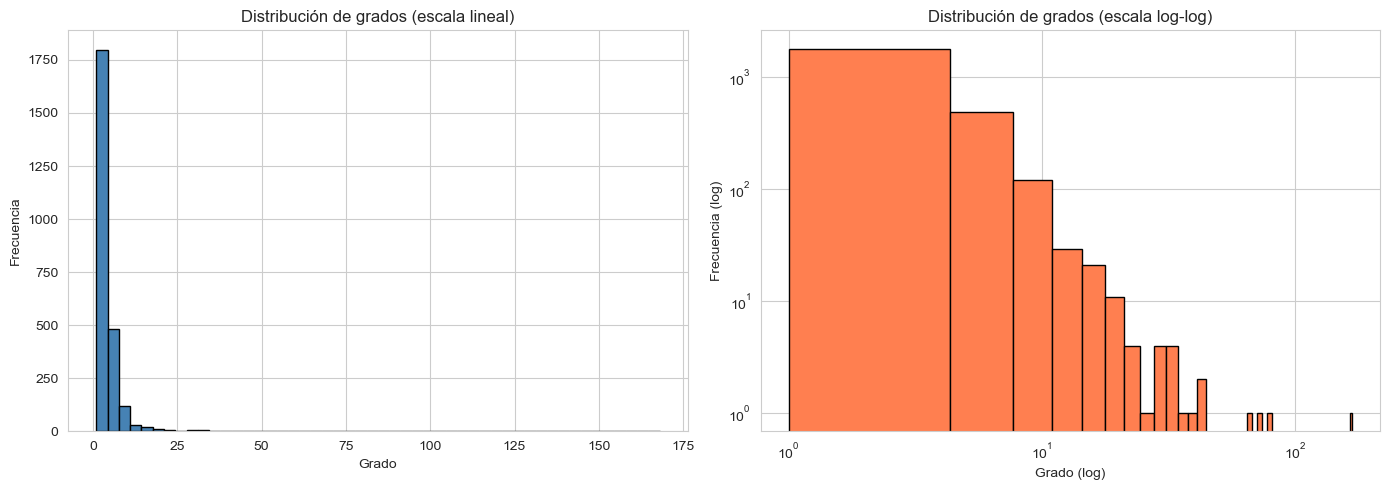

In [13]:
grados = [g for _, g in G.degree()]

print(f"Estadísticas del grado:")
print(f"  Media: {np.mean(grados):.2f}")
print(f"  Mediana: {np.median(grados):.2f}")
print(f"  Min: {min(grados)}, Max: {max(grados)}")
print(f"  Desv. típica: {np.std(grados):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma normal
axes[0].hist(grados, bins=50, color="steelblue", edgecolor="black")
axes[0].set_title("Distribución de grados (escala lineal)")
axes[0].set_xlabel("Grado")
axes[0].set_ylabel("Frecuencia")

# Histograma log-log: las redes reales suelen seguir power-law
axes[1].hist(grados, bins=50, color="coral", edgecolor="black")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Distribución de grados (escala log-log)")
axes[1].set_xlabel("Grado (log)")
axes[1].set_ylabel("Frecuencia (log)")

plt.tight_layout()
plt.show()

In [14]:
# Añadimos la clase como atributo de cada nodo en el grafo
clase_por_nodo = dict(zip(cora_content["paper_id"], cora_content["class"]))
nx.set_node_attributes(G, clase_por_nodo, "class")

# Asortatividad: ¿los nodos tienden a conectarse con otros de la misma clase?
asortatividad = nx.attribute_assortativity_coefficient(G, "class")
print(f"Coeficiente de asortatividad por clase: {asortatividad:.4f}")
print()
print("Interpretación:")
print("  Valor cercano a 1: papers de la misma clase se citan mucho entre sí.")
print("  Valor cercano a 0: las citas son independientes de la clase.")
print("  Valor negativo: papers se citan más con otras clases.")

Coeficiente de asortatividad por clase: 0.7637

Interpretación:
  Valor cercano a 1: papers de la misma clase se citan mucho entre sí.
  Valor cercano a 0: las citas son independientes de la clase.
  Valor negativo: papers se citan más con otras clases.


In [15]:
with open("../data/graph.pkl", "wb") as f:
    pickle.dump(G, f)

print(f"Grafo guardado en data/graph.pkl")
print(f"  Nodos: {G.number_of_nodes()}")
print(f"  Aristas: {G.number_of_edges()}")

Grafo guardado en data/graph.pkl
  Nodos: 2485
  Aristas: 5069


## 4. Cálculo de métricas relacionales

Caracterizamos cada nodo del grafo con un conjunto de métricas
relacionales que servirán como features para los modelos de clasificación.
Las agrupamos en tres familias:

- **Centralidad**: cuán "importante" o "bien posicionado" está un nodo
  en la red (degree, closeness, betweenness, PageRank, eigenvector).
- **Clustering local**: en qué medida los vecinos de un nodo están
  conectados entre sí (clustering coefficient, número de triángulos).
- **Estructura de comunidades**: a qué comunidad pertenece el nodo
  según el algoritmo de Louvain.

Adicionalmente añadimos el **k-core**, que indica la profundidad
estructural del nodo dentro del grafo.

### 4.1 Métricas de centralidad

**Degree**: número de vecinos directos. Captura popularidad local.

**Closeness centrality**: inverso de la distancia media a todos los
demás nodos. Alta cuando un nodo está "cerca" de todos los demás.

**Betweenness centrality**: proporción de caminos mínimos del grafo
que pasan por el nodo. Identifica nodos puente entre comunidades.

**PageRank**: importancia del nodo según el algoritmo de Google, que
modela la probabilidad de visitar un nodo en un paseo aleatorio.

**Eigenvector centrality**: importancia de un nodo en función de la
importancia de sus vecinos. Un nodo es importante si está conectado
con otros nodos importantes.

In [18]:
print("Calculando degree...")
degree = dict(G.degree())

print("Calculando closeness centrality...")
closeness = nx.closeness_centrality(G)

print("Calculando betweenness centrality (esto puede tardar 1-2 minutos)...")
betweenness = nx.betweenness_centrality(G)

print("Calculando PageRank...")
pagerank = nx.pagerank(G)

print("Calculando eigenvector centrality...")
eigenvector = nx.eigenvector_centrality(G, max_iter=1000)

print("Métricas de centralidad calculadas.")

Calculando degree...
Calculando closeness centrality...
Calculando betweenness centrality (esto puede tardar 1-2 minutos)...
Calculando PageRank...
Calculando eigenvector centrality...
Métricas de centralidad calculadas.


### 4.2 Clustering local

**Clustering coefficient**: fracción de pares de vecinos de un nodo
que también están conectados entre sí. Mide cuánto se "cierran" los
triángulos alrededor del nodo. Alto en redes con comunidades densas,
bajo en redes de tipo árbol.

**Triangles**: número absoluto de triángulos en los que participa el
nodo. Métrica complementaria al clustering coefficient.

In [20]:
print("Calculando clustering coefficient...")
clustering_coef = nx.clustering(G)

print("Calculando número de triángulos por nodo...")
triangles = nx.triangles(G)

print("Métricas de clustering calculadas.")

Calculando clustering coefficient...
Calculando número de triángulos por nodo...
Métricas de clustering calculadas.


### 4.3 k-core

Un nodo está en el **k-core** si pertenece al máximo subgrafo en el
que todos los nodos tienen grado ≥ k. Es una medida de "profundidad
estructural": nodos con k-core alto están en zonas densas y robustas
del grafo, nodos con k-core bajo están en la periferia.

In [22]:
print("Calculando k-core...")
kcore = nx.core_number(G)

print("Distribución de k-core values:")
print(Counter(kcore.values()))

Calculando k-core...
Distribución de k-core values:
Counter({3: 1065, 2: 820, 1: 434, 4: 166})


### 4.4 Detección de comunidades con Louvain

Aplicamos el algoritmo de **Louvain** para particionar el grafo en
comunidades. Louvain optimiza la **modularidad**, una medida de cuán
buena es una partición: alta cuando los nodos dentro de cada comunidad
están densamente conectados y las conexiones entre comunidades son
escasas.

A cada nodo le asignamos como feature el **ID de su comunidad**.
Aunque es un valor categórico arbitrario, los modelos basados en árboles
pueden aprovecharlo: si los artículos de la misma subárea tienden a caer
en la misma comunidad de Louvain (cosa esperable dada la alta
asortatividad), el ID de comunidad es un predictor potente.

In [24]:
import community as community_louvain

print("Calculando comunidades con Louvain...")
particion_louvain = community_louvain.best_partition(G, random_state=42)

n_comunidades = len(set(particion_louvain.values()))
modularidad = community_louvain.modularity(particion_louvain, G)

print(f"Número de comunidades detectadas: {n_comunidades}")
print(f"Modularidad de la partición: {modularidad:.4f}")

Calculando comunidades con Louvain...
Número de comunidades detectadas: 28
Modularidad de la partición: 0.8059


In [25]:
# ¿Las comunidades de Louvain capturan algo parecido a las clases reales?
# Para cada comunidad, vemos cuál es la clase más frecuente
from collections import defaultdict

comunidad_a_clases = defaultdict(list)
for nodo, com in particion_louvain.items():
    comunidad_a_clases[com].append(G.nodes[nodo]["class"])

# Mostramos las 10 comunidades más grandes
comunidades_ordenadas = sorted(comunidad_a_clases.items(), 
                                key=lambda x: len(x[1]), reverse=True)

print("Las 10 comunidades más grandes y su clase dominante:")
print(f"{'Com.':<6}{'Tamaño':<10}{'Clase dominante':<30}{'% pureza':<10}")
print("-" * 60)
for com_id, clases in comunidades_ordenadas[:10]:
    contador = Counter(clases)
    clase_dom, freq = contador.most_common(1)[0]
    pureza = 100 * freq / len(clases)
    print(f"{com_id:<6}{len(clases):<10}{clase_dom:<30}{pureza:<10.1f}")

Las 10 comunidades más grandes y su clase dominante:
Com.  Tamaño    Clase dominante               % pureza  
------------------------------------------------------------
1     275       Genetic_Algorithms            97.5      
12    208       Reinforcement_Learning        77.9      
19    204       Neural_Networks               71.1      
11    164       Rule_Learning                 47.6      
14    152       Theory                        26.3      
2     151       Neural_Networks               85.4      
18    138       Theory                        45.7      
22    132       Theory                        93.2      
6     124       Case_Based                    88.7      
5     111       Probabilistic_Methods         88.3      


## 5. Construcción del DataFrame de features relacionales

Convertimos todas las métricas calculadas en un DataFrame con una fila
por nodo. Antes de añadir el bag-of-words, validamos que todo cuadre.

In [27]:
nodos = list(G.nodes())

features_rel = pd.DataFrame({
    "node_id": nodos,
    "degree": [degree[n] for n in nodos],
    "closeness": [closeness[n] for n in nodos],
    "betweenness": [betweenness[n] for n in nodos],
    "pagerank": [pagerank[n] for n in nodos],
    "eigenvector_centrality": [eigenvector[n] for n in nodos],
    "clustering_coef": [clustering_coef[n] for n in nodos],
    "triangles": [triangles[n] for n in nodos],
    "kcore": [kcore[n] for n in nodos],
    "community_louvain": [particion_louvain[n] for n in nodos],
})

print(f"Forma del DataFrame de features relacionales: {features_rel.shape}")
print(f"\nPrimeras filas:")
features_rel.head()

Forma del DataFrame de features relacionales: (2485, 10)

Primeras filas:


,node_id,degree,closeness,betweenness,pagerank,eigenvector_centrality,clustering_coef,triangles,kcore,community_louvain
0,1033,5,0.198023,0.002886,0.000450,0.052207,0.100000,1,3,0
1,35,168,0.242768,0.276114,0.013302,0.654300,0.011406,160,4,1
2,103482,6,0.202958,0.005357,0.000572,0.050281,0.133333,2,3,2
3,103515,11,0.196706,0.001996,0.000899,0.072508,0.163636,9,3,1
4,1050679,4,0.225962,0.028597,0.000355,0.050567,0.166667,1,3,3


In [28]:
features_rel.describe()

,node_id,degree,closeness,betweenness,pagerank,eigenvector_centrality,clustering_coef,triangles,kcore,community_louvain
count,2.485000e+03,2485.000000,2485.000000,2.485000e+03,2485.000000,2.485000e+03,2485.000000,2485.000000,2485.000000,2485.000000
mean,4.848855e+05,4.079678,0.163170,2.138944e-03,0.000402,5.216083e-03,0.237636,1.880885,2.387525,11.713481
std,4.604418e+05,5.406362,0.026251,8.584245e-03,0.000432,1.937416e-02,0.314680,4.829323,0.848844,7.898358
min,3.500000e+01,1.000000,0.076192,0.000000e+00,0.000119,1.441334e-13,0.000000,0.000000,1.000000,0.000000
25%,5.611200e+04,2.000000,0.145476,3.242662e-07,0.000235,1.233710e-05,0.000000,0.000000,2.000000,3.000000
50%,2.652030e+05,3.000000,0.164449,4.335235e-04,0.000327,1.059074e-04,0.100000,1.000000,2.000000,12.000000
75%,1.107095e+06,5.000000,0.181605,1.677630e-03,0.000448,1.287525e-03,0.333333,2.000000,3.000000,19.000000
max,1.155073e+06,168.000000,0.242768,2.761143e-01,0.013302,6.542997e-01,1.000000,160.000000,4.000000,27.000000


In [29]:
print("¿Hay NaN en alguna columna?")
print(features_rel.isnull().sum())

¿Hay NaN en alguna columna?
node_id                   0
degree                    0
closeness                 0
betweenness               0
pagerank                  0
eigenvector_centrality    0
clustering_coef           0
triangles                 0
kcore                     0
community_louvain         0
dtype: int64
